## Contents overview:
This notebook documents the codes and their explanations essential for understanding and applying 
linear regression models using SVD approach and gradient descent approaches, 
polynomial regression models, 
detecting evidence of overfitting and underfitting using learning curves,
ridge regularization,
lasso regularization,
and elstic nets regularization.

note: 输入公式算的时候，X需要加上1列来计算intercept theta 0。如果直接用sklearn function计算，只需要输入不带1列的X就可以

## Linear regression using normal function and SVD approach:

In [1]:
import numpy as np
X = 2 * np.random.rand(100, 1)                # 生成100行1列，rand()是生成0～1的随机数，*2就把这个范围改成了0～2
y = 4 + 3 * X + np.random.randn(100, 1)       # np.random.randn(100, 1)生成100行1列的noise，～N(0,1)
X_b = np.c_[np.ones((100, 1)), X]             # 添加1列1向量，形状为100*1，拼在X矩阵前面形成新矩阵X_b

import numpy.linalg as la
theta_best = la.inv(X_b.T@X_b)@X_b.T@y          # 验证normal function可以找到最佳的coefficient estimate。这里theta0和theta1不等于4和3是因为添加了noise。但可以看到结果很接近
print(theta_best)                               # 其中(X.T @ X)^-1 @ X.T的结果就是X+，X的伪逆，X+ @ y同样可以计算出theta best

theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)        # 也可以用lstsq()计算theta最优解
theta_best_svd
np.linalg.pinv(X_b).dot(y)                      # 用pinv()@y 直接计算出theta最优解

X_new = np.array([[0],
                  [2]])
X_test = np.array([[1, 0],
                   [1, 2]])                  # 测试：当x=0和x=2时，预测y的取值。注意theta_best现在是2*1 vector，所以要算x_test @ theta_best。注意input格式
y_pred = X_test @ theta_best
print(y_pred)

[[3.96340915]
 [3.12523916]]
[[ 3.96340915]
 [10.21388748]]


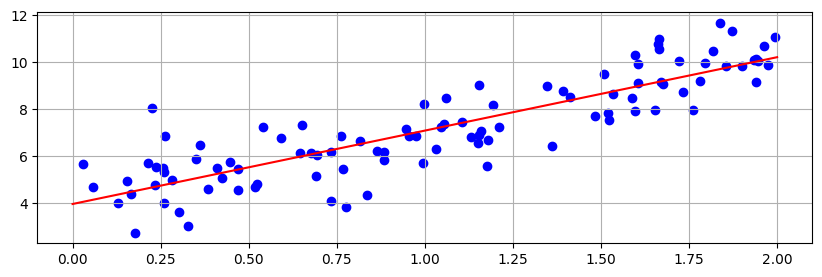

In [2]:
# 数据画图+预测直线画图
import matplotlib.pyplot as plt 
plt.figure(figsize = (10,3))                  # plt.figure每次会创建新画布，所以为了figure后面的内容显示在一张图上，应该把图片大小显示代码放在最上面一行写
plt.scatter(X, y, color='blue')
plt.plot(X_new, y_pred, color='red')
plt.grid(True)
plt.show()

In [ ]:
# perform linear regression using sklearn function:
from sklearn.linear_model import LinearRegression 
linear_model = LinearRegression()
linear_model.fit(X, y)                      # linear_model.intercept_; linear_model.coef_; linear_model.predict(X_new)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Gradient descent approach: faster than using SVD when there are many features
1. the MSE cost function of a linear regression model is convex: any line segment between two random points on the curve never cross with the curve. It means that there are only one global minimum. Therefore, when using gradient descent approach, the algorithm will converge close enough to the global minimum.

2. If the features of a dataset have distinct scales, then it will take a long time for the algorithm to converge. It is important to make sure that the features have similar scales before applying gradient descent approach to linear regression models. Use standard scaler so that all features have the same variance.



## Batch gradient descent:

gradient = $\frac{2}{m} X^T (X\theta - y)$

use gridsearch to find the optimal step size. Set a large number of iterations, stop the algorithm when the gradient is close to zero(less than tolerance $\epsilon$).

In [4]:
eta = 0.1                       # 设定step size
m = 100                         # 上面randomize生成了100个数据点
n_epochs = 1000                    # 设定运行1000次
theta = np.random.randn(2,1)    # 随机设定初始coefficient values

for i in range(n_epochs):
    gradients = 2/m * (X_b.T @ (X_b @ theta - y))
    theta = theta - eta * gradients
print(theta)                    # 输出结果和LinearRegression()结果一样

[[3.96340915]
 [3.12523916]]


## Stochastic gradient descent:

In [5]:
m = 100
n_epochs = 50
theta = np.random.randn(2,1)                            # 初始coefficient values随机化
t0, t1 = 5, 50
def learning_rate(t):                                   # 定义学习率。输入t是已经学习了多久。随着学习时间变长，学习率降低，每一步新的迭代step size变小。
    return t0/(t + t1)
for epoch in range(n_epochs):                           # range(n)是0到n-1
    for i in range(m):
        random_index = np.random.randint(0, m)
        xi = X_b[random_index:random_index+1, :]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_rate(epoch * m + 1)
        theta = theta - eta * gradients
theta

from sklearn.linear_model import SGDRegressor                               # 用SDGRegressor()函数，tolerance=0.001，learning schedule为默认
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([3.95967537]), array([3.16971339]))

## Polynomial regression:

In [6]:
m = 100                                                                 # 生成数据，y = 2 + x + 0.5x^2 + noise
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)                                 # 生成最高次项=2的对应的X数据，X里只有一个feature，所以这里只会生成x与x^2。现在X_poly里会有新的feature是x^2

from sklearn.linear_model import LinearRegression                       # 用LinearRegression()对新生成的feature建模，因为polynomial regression的coefficients依旧是线性的。多项式回归还是线性模型
linear_model = LinearRegression()
linear_model.fit(X_poly, y)
print(linear_model.intercept_, linear_model.coef_)

X_new = np.array([[0],
                  [2]])
X_test = poly_features.fit_transform(X_new)               
y_pred = linear_model.predict(X_test)
print(y_pred)

[2.03833238] [[1.03309757 0.47262852]]
[[2.03833238]
 [5.99504162]]


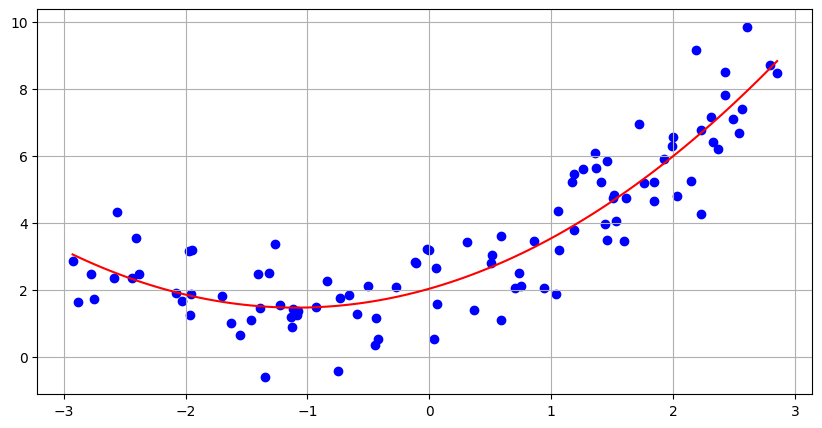

In [ ]:
X_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)           # 在X最大值与X最小值之间生成间隔一样的100个数据点。现在的shape是(100, )。reshape到(100, 1)。（-1，1）代表有几个样本生成几行的新维度
X_fit_poly = poly_features.transform(X_fit)
y_fit = linear_model.predict(X_fit_poly)

plt.figure(figsize = (10, 5))
plt.scatter(X, y, color = 'blue')
plt.plot(X_fit, y_fit, color = 'red')       # plot()是把散点连成平滑曲线的
plt.grid(True)
plt.show()


## Learning curve:
It helps to detect evidence of overfitting and underfitting problems

In [19]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)        # 没有test set，只有80%作为训练集，20%作为验证集
    train_errors = []
    val_errors = []
    for m in range(1, len(X_train)):                    # 从1个样本逐渐增加到整个训练集-1个样本
        model.fit(X_train[0:m], y_train[0:m])           # 只取前m个训练数据用来训练模型
        y_train_predict = model.predict(X_train[0:m])   # 训练数据predict
        y_val_predict = model.predict(X_val)            # validation数据，也就是模型没见过的数据predict
        train_errors.append(mean_squared_error(y_train[0:m], y_train_predict))      # 看模型在训练数据上的表现
        val_errors.append(mean_squared_error(y_val, y_val_predict))                 # 看模型在validation数据上的表现
    plt.plot(np.sqrt(train_errors), color = 'red', label = 'train')
    plt.plot(np.sqrt(val_errors), color = 'blue', label = 'test')
    plt.legend()
    plt.xlim(0, 80)
    plt.ylim(0, 3)
    plt.title("Learning Curves")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    
    # plt.savefig("learning_curve.png", dpi=300, bbox_inches="tight") 用这个代码可以保存输出图片为高清版本
    plt.show()


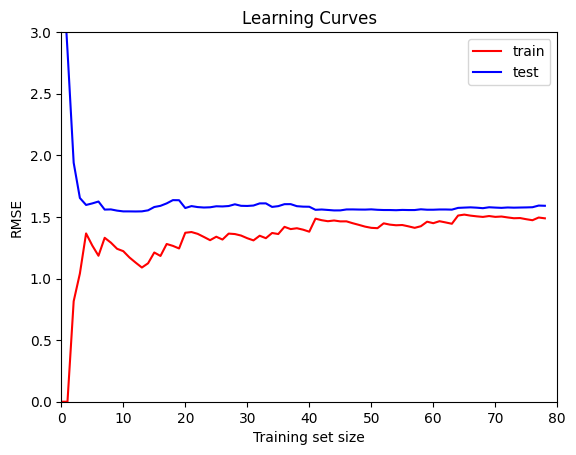

In [ ]:
linear_model = LinearRegression()
plot_learning_curves(linear_model, X, y)        # evidence of underfitting

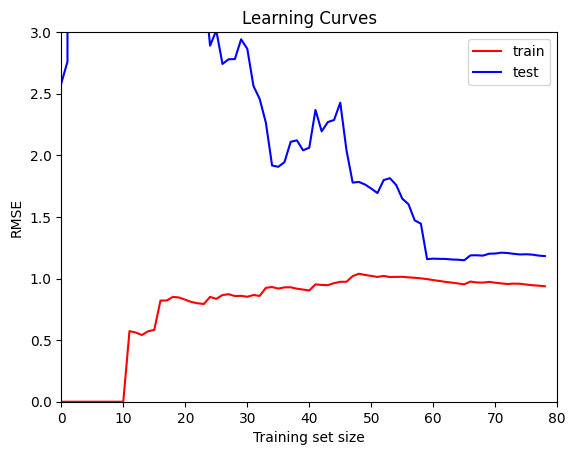

In [ ]:
# evidence of overfitting:
from sklearn.pipeline import Pipeline 
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 10, include_bias = False)),       # 定义：poly_features = PolynomialFeatures(degree = 10, include_bias = False)
    ('lin_reg', LinearRegression()),                                                # 定义：lin_reg = LinearRegression()
])
plot_learning_curves(polynomial_regression, X, y)
# polynomial_regression.predict()      

# pipeline中间的部分是transformer，都只接受一个input，并且pipeline(model, input 1, input 2)默认把input 1放到中间的transformer中
# 也就是先poly_features.fit(X)，然后输出一个结果比如叫a，然后再把a送到下一个函数lin_reg，lin_reg是这个pipeline最后一个处理，所以可以对输出a和外部input 2做fit, transform, predict

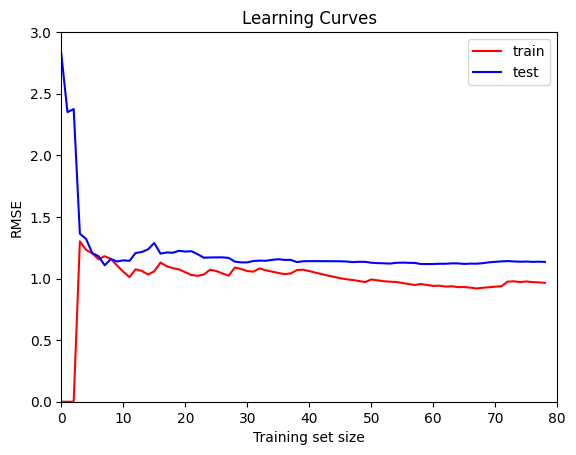

In [ ]:
from sklearn.pipeline import Pipeline 
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree = 2, include_bias = False)),
    ('lin_reg', LinearRegression()),
])
plot_learning_curves(polynomial_regression, X, y)           # overall better than degree=1 and degree=10

## Regularization methods:
ridge, lasso, elastic net, and early stopping. They can all avoid overfitting problems.

## Ridge regression:
can constrain the coefficients but cannot set them to be equal to 0

In [ ]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])


# 选择alpha取值：
# from sklearn.linear_model import RidgeCV
# ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
# ridge_cv.fit(X, y)
# print("Best alpha:", ridge_cv.alpha_)

array([4.91063453])

## Lasso regression:
can set the coefficients of some less useful features to 0

In [30]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.86772357])

## Elastic net:
a middle ground between lasso and ridge, and the weight can be set manually. Useful when collinearity exists between features, or when # of features > # of observations in the training set

In [ ]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)           # l1_ratio对应的是elastic net的cost function中的r的数值
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.86722311])

## Early stopping:

In [37]:
from copy import deepcopy                 # clone()可以复制当前模型形态
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

poly_scaler = Pipeline([                                                            # 处理数据
    ('poly_features', PolynomialFeatures(degree = 90, include_bias = False)),
    ('std_scaler', StandardScaler())
])
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

minimum_val_error = float('inf')
best_epoch = None 
best_model = None

sgd_reg = SGDRegressor(
    max_iter=1,
    tol=None,
    warm_start=True,
    penalty=None,
    learning_rate='constant',
    eta0=0.0005
)
# warm start = True: 每次用上次训练后的参数继续训练，而不是重新randomize coefficient然后重新gradient descent    
# max_iter代表每次调用sgd_reg.fit()的时候只做一轮(1 epoch)，也就是只把训练集的每个样本都过一遍，每过一个样本更新一次coefficients
# 通过设定max_iter = 1，搭配epoch的for loop就可以做到单独分析每一轮的结果而不是一次性的运行多轮出一个结果，或者手动操作1000轮训练每次结束单独分析

for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error 
        best_epoch = epoch 
        best_model = deepcopy(sgd_reg)




/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/uti

In [39]:
print(best_model.intercept_,best_model.coef_)

[3.6708132] [ 1.66699669e+00  1.05157395e+00  2.00067891e-01  2.94398037e-01
 -1.70238021e-01  6.30754801e-02 -1.59279105e-01  5.10772080e-03
 -7.74091582e-02 -9.10263562e-03 -6.35005737e-03 -1.51820837e-02
  4.09126932e-02 -2.12442325e-02  6.78414486e-02 -2.80333362e-02
  8.02024432e-02 -3.46939569e-02  8.28473846e-02 -4.03578745e-02
  7.93234533e-02 -4.44953140e-02  7.21022561e-02 -4.69074789e-02
  6.28689676e-02 -4.76334495e-02  5.27546296e-02 -4.68560479e-02
  4.25042021e-02 -4.48290321e-02  3.25945800e-02 -4.18274053e-02
  2.33170427e-02 -3.81166071e-02  1.48350193e-02 -3.39354288e-02
  7.22473238e-03 -2.94882038e-02  5.03881774e-04 -2.49428879e-02
 -5.34810081e-03 -2.04326237e-02 -1.03757843e-02 -1.60591642e-02
 -1.46377479e-02 -1.18971030e-02 -1.81996573e-02 -7.99826229e-03
 -2.11295419e-02 -4.39586521e-03 -2.34946484e-02 -1.10829784e-03
 -2.53594209e-02  1.85761972e-03 -2.67842792e-02  4.50386477e-03
 -2.78249558e-02  6.83891854e-03 -2.85322204e-02  8.87590065e-03
 -2.89518660e